In [3]:
import plotly.express as px
from config import df

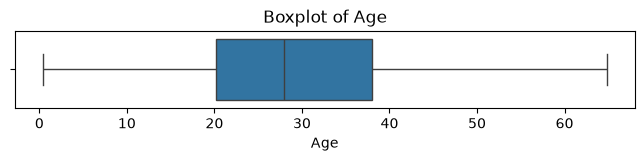

In [8]:
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df
import matplotlib.pyplot as plt
import seaborn as sns
def plot_outliers(df, column):
    plt.figure(figsize=(8, 1))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()
import pandas as pd
import numpy as np
from config import DROP_COLS
from processing import drop_columns
df = pd.read_csv('titanic.csv')
df = drop_columns(df,DROP_COLS)
replace_outliers(df, 'Age')  # Example usage for the first column in DROP_COLS
plot_outliers(df, 'Age')  # Example usage for the first column in DROP_COLS

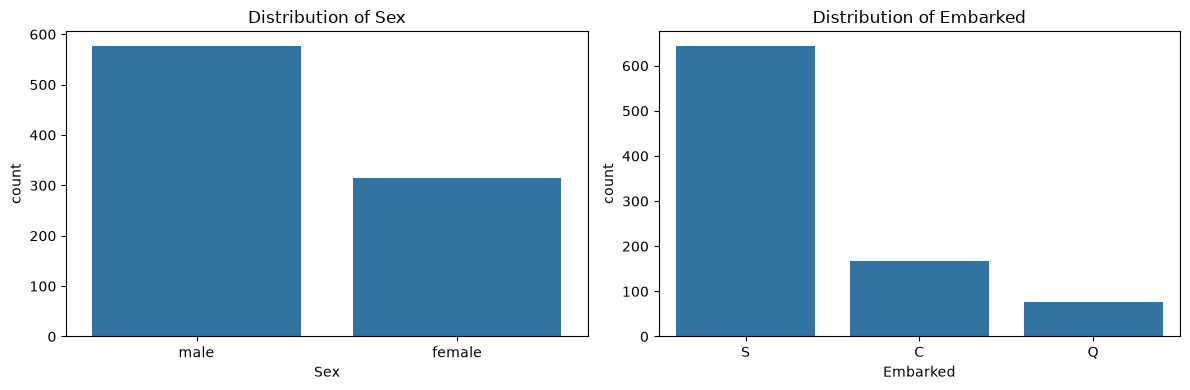

In [8]:
from config import df, clos_categorical_cols
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_distribution(cols):
    num_cols = len(cols)
    plt.figure(figsize=(6 * num_cols, 4))  # ضبط حجم اللوحة حسب عدد الأعمدة
    
    for i, column in enumerate(cols):
        # 1: عدد الصفوف، num_cols: عدد الأعمدة، i + 1: رقم الرسمة الحالية
        plt.subplot(1, num_cols, i + 1)  
        sns.countplot(x=df[column])
        plt.title(f'Distribution of {column}')
        
    plt.tight_layout()  # لمنع تداخل العناوين والأسماء
    plt.show()

# استدعاء الدالة
plot_categorical_distribution(clos_categorical_cols)

In [ ]:
fig=px.pie(df,names='Sex',title='Distribution of Sex')
fig.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from config import df

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
scaler.fit(df[num_cols])

In [ ]:
from category_encoders import OneHotEncoder
from config import df, clos_categorical_cols
encoder = OneHotEncoder(cols=clos_categorical_cols,drop_invariant=True,use_cat_names=True)
df = encoder.fit_transform(df)

,PassengerId,Survived,Pclass,Name,Sex_male,Sex_female,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_S,Embarked_C,Embarked_Q,Embarked_nan
0,1,0,3,"Braund, Mr. Owen Harris",1,0,22.0,1,0,A/5 21171,7.2500,NaN,1,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,38.0,1,0,PC 17599,71.2833,C85,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,35.0,1,0,113803,53.1000,C123,1,0,0,0
4,5,0,3,"Allen, Mr. William Henry",1,0,35.0,0,0,373450,8.0500,NaN,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,0,27.0,0,0,211536,13.0000,NaN,1,0,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,1,19.0,0,0,112053,30.0000,B42,1,0,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,1,NaN,1,2,W./C. 6607,23.4500,NaN,1,0,0,0
889,890,1,1,"Behr, Mr. Karl Howell",1,0,26.0,0,0,111369,30.0000,C148,0,1,0,0
